In [1]:
import os
import argparse
import numpy as np
import pandas as pd
from decimal import *
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def update_delta(gamma_j, beta):
    return 1/gamma_j * ((gamma_j*(beta - 1) + 1)**(1/(1 - beta)))

def update_eff(n_a, E_o, S_o, delta_e, k_C, n_d):
    # if E_o - n_a* S_o is positive, the exponential value of this expression will explode in calculation.
    # The original form of efficiency formula contains negative exponent and
    # the simplified form contains the positive exponent
    
    if (E_o - n_a*S_o) >= 0:
        return n_d * (n_a - \
                        ((E_o - n_a*S_o)*n_a*np.exp(-(E_o - n_a * S_o) * k_C * delta_e))/ \
                        (E_o - n_a*S_o*np.exp(-(E_o - n_a*S_o) * k_C * delta_e)))
    else:
        return n_d * (n_a - \
                    ((E_o - n_a*S_o) * n_a)/ \
                        (E_o * np.exp((E_o - n_a * S_o) * k_C * delta_e) - n_a * S_o))
    
def simulate_vals(D_init, E_init, P_init, delta_e, n_d, n_dE, k_C, beta, n_cycle=50):
    S_o, gamma, delta, n_a, eff = [], [], [], [], []
    P_o, E_o, D_e = [P_init], [E_init], [D_init]

    n_cycle = int(n_cycle)
    # print(n_cycle)

    for i in range(n_cycle):
        S_o_j = n_d*D_e[i]
        S_o.append(S_o_j)

        gamma_j = S_o_j/(P_o[i] + Decimal(1e-200))
        gamma.append(gamma_j)
        
        # print(gamma_j)

        delta_j = update_delta(gamma_j, beta=beta)
        delta.append(delta_j)

        n_a_j = 1/gamma_j - delta_j
        n_a.append(n_a_j)

        E_o_j = (n_dE**(i+1)) * E_o[0]
        E_o.append(E_o_j)

        eff_j = update_eff(n_a=n_a_j, E_o=E_o_j, S_o=S_o_j, delta_e=delta_e, k_C=k_C, n_d=n_d)
        eff.append(eff_j)
        # print('At cycle {}, PCR efficiency is {}'.format(i, eff_j))

        D_e_j = (eff_j + 1)*D_e[i]
        D_e.append(D_e_j)

        P_o_j = P_o[i] - eff_j * S_o_j
        P_o.append(P_o_j)
    
    return eff, n_a, D_e, S_o, E_o, P_o, gamma, delta

In [5]:
curves, params = [], []
for i in range(30):
    curve_dict = pd.read_pickle(f'data/simulated_database/file_{i}.pkl')
    curves.extend([[float(str(y)) for y in x] for x in curve_dict['curves']])
    params.extend([[float(str(y)) for y in x] for x in curve_dict['params']])

print(len(curves))
print(len(params))

974686
974686


In [3]:
def curve_dist(c1, c2):
    return np.mean((c1[10:] - c2[10:])**2)

In [5]:
import sklearn
from sklearn.neighbors import NearestNeighbors

curves = np.array(curves)
params = np.array(params)

for i in range(5):
    # print(curves[i])
    # print(params[i])
    pass

nbrs = NearestNeighbors(n_neighbors=10, algorithm='ball_tree')
nbrs.fit(curves)
dists, indices = nbrs.kneighbors(curves)

In [ ]:
import random
import pickle

# print(dists[:5])
# print(indices[:5])

for k in range(5):
    idx = random.randint(0, len(curves) - 1)
    plt.plot(curves[idx], label = 'initial curve')
    for i in indices[idx]:
        # print(params[i])
        plt.plot(curves[i], label = f'neighbor {i}', c='r')
    plt.legend()
    plt.grid()
    plt.show()

knnPickle = open('knnPickle', 'wb')
pickle.dump(nbrs, knnPickle)
knnPickle.close()

In [6]:
import pickle
import sklearn
from sklearn.neighbors import KNeighborsRegressor

knn_regress = KNeighborsRegressor(n_neighbors=2)
knn_regress.fit(curves, params)

knnRegressPickle = open('knnRegressPickle', 'wb')
pickle.dump(knn_regress, knnRegressPickle)
knnRegressPickle.close()

True Parameters: ['2.2e+11', '1.46218e+07', '1.804e+11', '0.2', '5.0']
Pred Parameters: ['1.8e+11', '1.46218e+07', '1.8e+11', '0.2', '5.0']
True Parameters: ['4e+10', '2.19328e+07', '4.24e+10', '0.9', '10.0']
Pred Parameters: ['4e+10', '2.19328e+07', '2.2e+10', '0.9', '10.0']
True Parameters: ['5.4e+11', '8.57143e+06', '4.752e+11', '0.9', '100.0']
Pred Parameters: ['5.4e+11', '8.82353e+06', '4.752e+11', '0.9', '100.0']
True Parameters: ['4.2e+11', '2.84874e+07', '3.57e+11', '0.433333', '10.0']
Pred Parameters: ['3.8e+11', '2.84874e+07', '3.572e+11', '0.433333', '10.0']
True Parameters: ['1.4e+11', '1.76471e+07', '1.4e+11', '0.666667', '10.0']
Pred Parameters: ['1.6e+11', '1.66387e+07', '1.408e+11', '0.666667', '5.0']


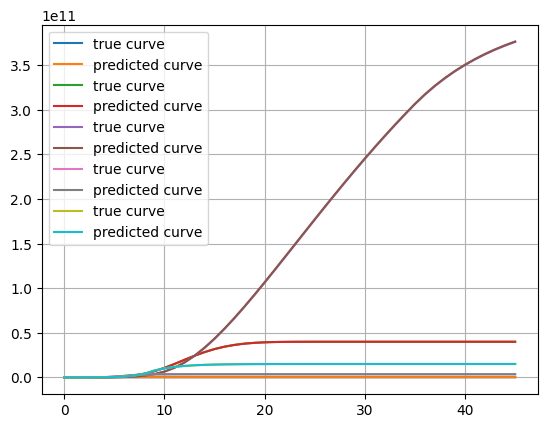

In [16]:
import random

def plot_curve(cur_params, offset = 0):
    try:
        D_e_pred = simulate_vals(D_init=Decimal(cur_params[1]),
                    E_init=Decimal(cur_params[2]), 
                    P_init=Decimal(cur_params[0]), 
                    delta_e=Decimal(20),
                    n_d=Decimal(1),
                    n_dE=Decimal(cur_params[3]),
                    k_C=Decimal(1),
                    beta=Decimal(cur_params[4]),
                    n_cycle=45)[2]
        D_e_pred = np.array([float(str(x)) + offset for x in D_e_pred])
        return D_e_pred
    except:
        return []

for k in range(5):
    idx = random.randint(0, len(curves) - 1)
    params_pred = knn_regress.predict([curves[idx]])[0]

    params_second = params_pred * 2 - params[idx]

    print('True Parameters:', [f'{x:.6}' for x in params[idx]])
    print('Pred Parameters:', [f'{x:.6}' for x in params_second])

    plt.plot(plot_curve(params[idx]), label = 'true curve')
    plt.plot(plot_curve(params_second), label = 'predicted curve')
    plt.legend()
    plt.grid()
    # plt.show()

    

100%|██████████| 1000/1000 [01:08<00:00, 14.50it/s]


R^2 Value for All Params: 0.00010644975477882893
Parameter Ranges: 1.5273134128216577e-22 2.3144595418754434


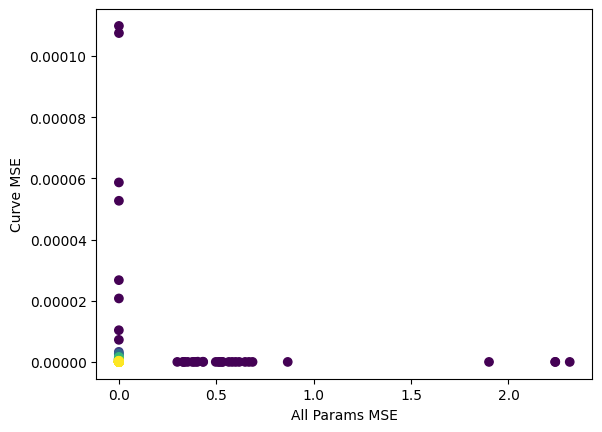

R^2 Value for P_init: 0.00010963101321579288
Parameter Ranges: 0.0 5.913768966467449


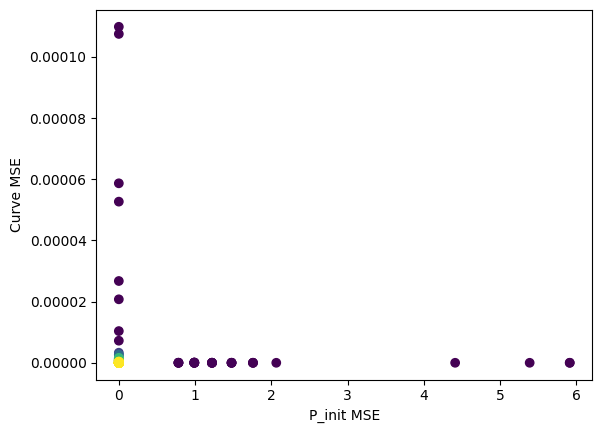

R^2 Value for D_init: 6.0759452277420165e-06
Parameter Ranges: 0.0 1.941366751535589e-12


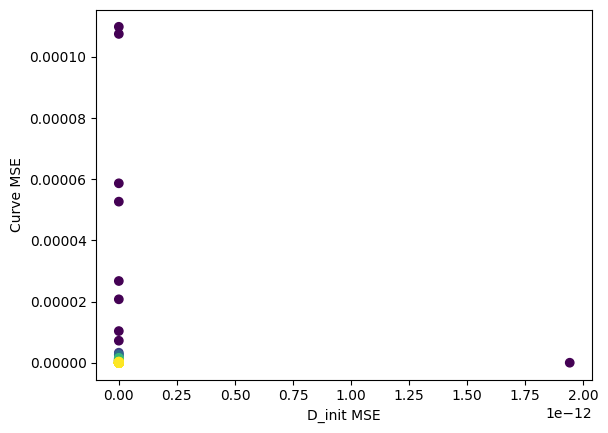

R^2 Value for E_init: 0.00010281887233375195
Parameter Ranges: 0.0 5.812063136922039


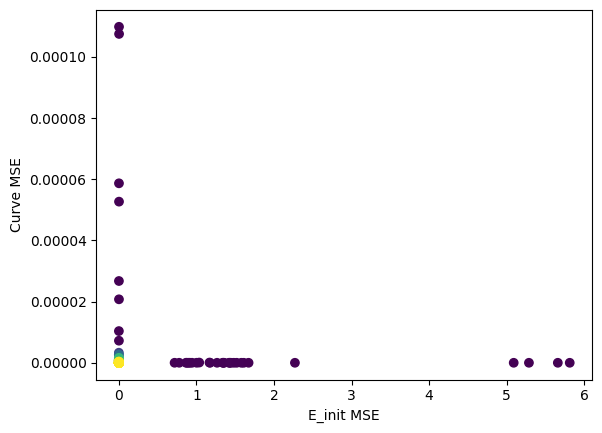

R^2 Value for n_dE: 0.00018497563521683414
Parameter Ranges: 0.0 4.1578965048027e-25


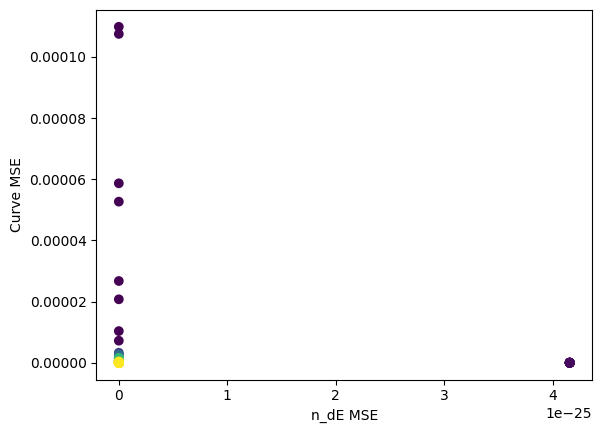

R^2 Value for beta: 0.0007205820702697565
Parameter Ranges: 0.0 3.024162784221001e-17


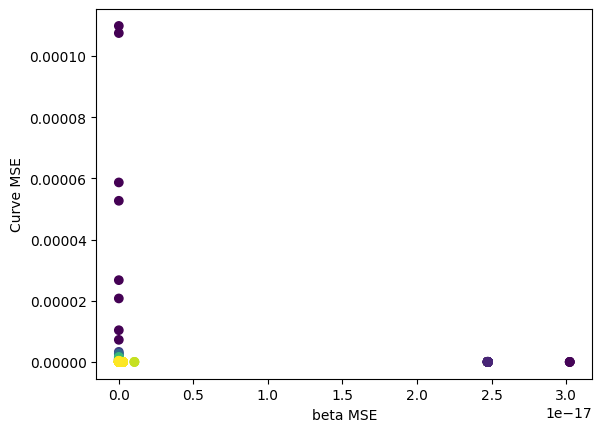

In [43]:
from scipy.stats import gaussian_kde

params_dists, curve_dists, p_dists = [], [], [[] for _ in range(5)]
curves_mean, curves_std = np.mean(curves), np.std(curves)
params_mean, params_std = np.mean(params), np.std(params)

for i in tqdm(range(1000)):
    idx = random.randint(0, len(curves) - 1)
    cur_curve = curves[i]
    cur_params = params[i]

    params_pred = knn_regress.predict([cur_curve])[0]
    params_second = params_pred * 2 - cur_params
    curve_second = plot_curve(params_second)

    if not len(curve_second):
        continue

    # limits = [0.2e23, 1e10, 0.2e23, 0.002, 0.2e6]
    # if False in [limits[x] < params_second[x] for x in range(5)]:
    #     continue

    cur_params_norm = (cur_params - params_mean) / params_std
    params_second_norm = (params_second - params_mean) / params_std
    cur_curve_norm = (cur_curve - curves_mean) / curves_std
    curve_second_norm = (curve_second - curves_mean) / curves_std

    params_mse = np.mean((cur_params_norm - params_second_norm)**2)
    curves_mse = curve_dist(cur_curve_norm, curve_second_norm)

    params_dists.append(params_mse)
    curve_dists.append(curves_mse)

    for j in range(5):
        p_dists[j].append((cur_params_norm[j] - params_second_norm[j])**2)


final_param_dists = [params_dists] + p_dists
labels = ['All Params', 'P_init', 'D_init', 'E_init', 'n_dE', 'beta']
# curve_dists_norm = (curve_dists - np.mean(curve_dists)) / np.std(curve_dists)

for i, p in enumerate(final_param_dists):

    # p = (p - np.mean(p)) / np.std(p)

    corr_matrix = np.corrcoef(p, curve_dists)
    print(f'R^2 Value for {labels[i]}:', corr_matrix[0,1]**2)
    print('Parameter Ranges:', min(p), max(p))

    xy = np.vstack([p, curve_dists])
    z = gaussian_kde(xy)(xy)

    plt.scatter(p, curve_dists, c=z)
    # plt.scatter(np.log(p), np.log(curve_dists), c=z)
    plt.xlabel(f"{labels[i]} MSE")
    plt.ylabel("Curve MSE")
    plt.show()

True Parameters: ['5.27413e+11', '1.48118e+07', '2.63052e+11', '0.619828', '388.918']
Pred Parameters: ['1.2e+11', '1.69412e+07', '1.0488e+11', '0.666667', '100.0']


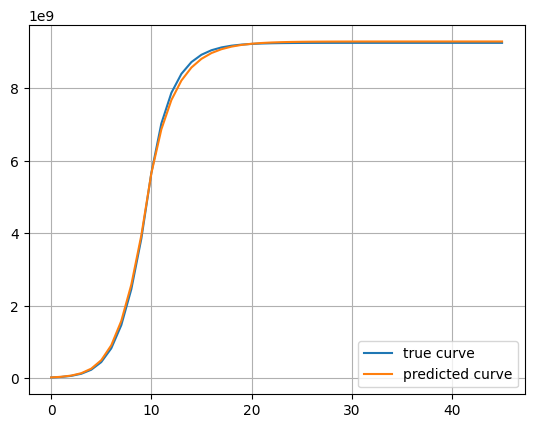

In [28]:
# Reading in initial curve for comparison
known_df = pd.read_csv('./data/known_dilution_multicomponent.csv')
known_df.head(2)
curve = known_df.loc[(known_df.loc[:,'Well Position'] == 'A1'), 'FAM']
curve = np.array(curve)

for i in range(1):
    cur_params = [random.uniform(2e10, 6e11), random.uniform(3e-3, 3e7), random.uniform(0.79*2e10, 1.06*6e11), random.uniform(0.2, 0.9), random.uniform(5,1000)]
    cur_curve = plot_curve(cur_params)
    # cur_curve = np.append(curve, curve[-1]) - curve[0]
    pred_params = knn_regress.predict([cur_curve])[0]

    print('True Parameters:', [f'{x:.6}' for x in cur_params])
    print('Pred Parameters:', [f'{x:.6}' for x in pred_params])

    plt.plot(cur_curve, label = 'true curve')
    plt.plot(plot_curve(pred_params), label = 'predicted curve')
    plt.legend()
    plt.grid()
    plt.show()

In [33]:
# Squared distance in parameters vs squared distance of curves
# If we see a linear/positive relationship that does not disprove
# If we see a fairly random distribution that disproves optimization procedures
# Take squared error for each parameter separately
# Also take for combined metrics